# Deep CFR: Target Reparameterization

Compare four ways of representing the sampled instantaneous-advantage target on the varied-harder spec. Every variant stores the same raw traversal records, uses the baseline infoset encoding, and receives the same measured training-time budget.

Variants:

- `raw positive-weighted`: current reference, raw regrets with positive action weight `beta=0.5`.
- `normalized per record`: divide each sampled legal regret vector by its maximum absolute value before regression.
- `sign + magnitude`: separately predict positivity and absolute magnitude, then reconstruct signed regrets.
- `direct regret-matched strategy`: directly predict the strategy induced by each sampled regret vector.

The last three deliberately change the approximation problem. Rank them primarily by exact generated-average exploitability and normalized AUC, not by their incomparable representation losses.

In [1]:
import gc
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'liars_poker').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from liars_poker.algo.deep_cfr import DeepCFRTrainer
from liars_poker.algo.deep_cfr_diagnostics import ExactDenseStrategyAverager
from liars_poker.core import GameSpec, possible_starting_hands
from liars_poker.policies.neural import NeuralMLP
from liars_poker.policies.tabular_dense import DenseTabularPolicy
from liars_poker.training.deep_cfr import deep_cfr_timed_loop


In [2]:
spec = GameSpec(
    ranks=4,
    suits=4,
    hand_size=3,
    claim_kinds=('RankHigh', 'Pair', 'Trips'),
    suit_symmetry=True,
)

training_seconds = 10 * 60
seed = 17
traversals_per_player = 50
eval_every = 10

COMMON_KWARGS = {
    'hidden_sizes': (256, 256),
    'advantage_buffer_capacity': 100_000,
    'strategy_buffer_capacity': 100_000,
    'batch_size': 128,
    'advantage_train_steps': 100,
    'strategy_train_steps': 50,
    'learning_rate': 1e-3,
    'strategy_weighting': 'linear',
    'highest_regret_fallback': True,
    'alternating_updates': True,
    'retrain_advantage_from_scratch': False,
    'validation_fraction': 0.05,
    'validation_buffer_capacity': 10_000,
}

spec.to_short_str(), training_seconds


('r4_s4_h3_hpt_ss', 600)

## Variant implementation

All variants retain raw sampled advantages in the reservoir. The trainer changes only how those records are fitted and converted into a current strategy. This keeps traversal target generation comparable while allowing deliberately different approximation maps.

In [3]:
class TargetReparameterizedDeepCFRTrainer(DeepCFRTrainer):
    VARIANTS = {'raw', 'normalized', 'sign_magnitude', 'direct_strategy'}

    def __init__(self, spec, *, target_variant='raw', positive_beta=0.5, sign_loss_weight=1.0, magnitude_loss_weight=1.0, **kwargs):
        super().__init__(spec, **kwargs)
        if target_variant not in self.VARIANTS:
            raise ValueError(f'Unknown target_variant: {target_variant}')
        self.target_variant = target_variant
        self.positive_beta = float(positive_beta)
        self.sign_loss_weight = float(sign_loss_weight)
        self.magnitude_loss_weight = float(magnitude_loss_weight)

        if target_variant == 'sign_magnitude':
            self.advantage_nets = [
                NeuralMLP(self.encoder.input_dim, 2 * self.encoder.action_dim, self.hidden_sizes).to(self.device)
                for _ in range(2)
            ]
            self.advantage_optimizers = [
                torch.optim.Adam(model.parameters(), lr=self.learning_rate)
                for model in self.advantage_nets
            ]

    def _regret_match(self, values, mask):
        positive = torch.relu(values) * mask
        totals = positive.sum(dim=1, keepdim=True)
        matched = positive / totals.clamp_min(1e-8)
        masked_values = values.masked_fill(mask <= 0.0, -torch.inf)
        fallback = torch.zeros_like(values).scatter_(1, masked_values.argmax(dim=1, keepdim=True), 1.0)
        return torch.where(totals > 0.0, matched, fallback)

    def _normalize_targets(self, targets, mask):
        scale = (targets.abs() * mask).amax(dim=1, keepdim=True).clamp_min(1e-6)
        return targets / scale, scale

    def _signed_regrets(self, output):
        action_dim = self.encoder.action_dim
        sign_logits = output[:, :action_dim]
        magnitude = F.softplus(output[:, action_dim:])
        signed_score = 2.0 * torch.sigmoid(sign_logits) - 1.0
        return signed_score * magnitude

    def _strategy_from_output(self, output, mask):
        if self.target_variant == 'direct_strategy':
            logits = output.masked_fill(mask <= 0.0, -1e9)
            return torch.softmax(logits, dim=1)
        regrets = self._signed_regrets(output) if self.target_variant == 'sign_magnitude' else output
        return self._regret_match(regrets, mask)

    def _advantage_per_sample_loss(self, output, targets, mask):
        mask_float = mask.float()
        positive_weight = mask_float * (1.0 + self.positive_beta * (targets > 0.0).float())

        if self.target_variant == 'raw':
            squared = (output - targets).square() * positive_weight
            return squared.sum(dim=1) / positive_weight.sum(dim=1).clamp_min(1.0)

        if self.target_variant == 'normalized':
            normalized, _ = self._normalize_targets(targets, mask_float)
            squared = (output - normalized).square() * positive_weight
            return squared.sum(dim=1) / positive_weight.sum(dim=1).clamp_min(1.0)

        if self.target_variant == 'sign_magnitude':
            action_dim = self.encoder.action_dim
            sign_logits = output[:, :action_dim]
            predicted_magnitude = F.softplus(output[:, action_dim:])
            sign_target = (targets > 0.0).float()
            sign_loss = F.binary_cross_entropy_with_logits(sign_logits, sign_target, reduction='none') * mask_float
            magnitude_loss = (predicted_magnitude - targets.abs()).square() * positive_weight
            sign_per_sample = sign_loss.sum(dim=1) / mask_float.sum(dim=1).clamp_min(1.0)
            magnitude_per_sample = magnitude_loss.sum(dim=1) / positive_weight.sum(dim=1).clamp_min(1.0)
            return self.sign_loss_weight * sign_per_sample + self.magnitude_loss_weight * magnitude_per_sample

        target_strategy = self._regret_match(targets, mask_float)
        logits = output.masked_fill(~mask, -1e9)
        return -(target_strategy * torch.log_softmax(logits, dim=1)).sum(dim=1)

    def _train_model(self, model, optimizer, buffer, steps, *, strategy_loss):
        if strategy_loss:
            return super()._train_model(model, optimizer, buffer, steps, strategy_loss=True)
        if buffer.size == 0 or steps <= 0:
            return 0.0

        model.train()
        total_loss = 0.0
        for _ in range(steps):
            features, targets, masks, weights = buffer.sample(self.batch_size, self.rng)
            x = torch.from_numpy(features).to(self.device)
            y = torch.from_numpy(targets).to(self.device)
            mask = torch.from_numpy(masks).to(self.device)
            sample_weight = torch.from_numpy(weights).to(self.device)
            sample_weight = sample_weight / sample_weight.mean().clamp_min(1e-8)

            output = model(x)
            per_sample = self._advantage_per_sample_loss(output, y, mask)
            loss = (per_sample * sample_weight).mean()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += float(loss.detach().cpu())

        model.eval()
        return total_loss / steps

    def _strategy_from_features(self, pid, features, legal):
        x = torch.from_numpy(features).to(self.device).unsqueeze(0)
        mask = torch.zeros((1, self.encoder.action_dim), dtype=torch.float32, device=self.device)
        mask[0, [self._action_col(action) for action in legal]] = 1.0
        with torch.no_grad():
            strategy = self._strategy_from_output(self.advantage_nets[pid](x), mask)[0]
        return strategy.cpu().numpy()

    def current_policy_dense(self, *, batch_size=4096):
        dense = DenseTabularPolicy(self.spec)
        hands = tuple(possible_starting_hands(self.spec))
        for hid in range(1 << self.encoder.k):
            history = tuple(action for action in range(self.encoder.k) if hid & (1 << action))
            legal = dense.legal_actions[hid]
            cols = [self._action_col(action) for action in legal]
            model = self.advantage_nets[dense.pid_to_act(hid)]
            mask = torch.zeros((1, self.encoder.action_dim), dtype=torch.float32, device=self.device)
            mask[0, cols] = 1.0
            for start in range(0, len(hands), batch_size):
                stop = min(start + batch_size, len(hands))
                features = self.encoder.encode_hands(hands[start:stop], history)
                x = torch.from_numpy(features).to(self.device)
                with torch.no_grad():
                    probs = self._strategy_from_output(model(x), mask.expand(stop - start, -1)).cpu().numpy()
                block = dense.S[hid, start:stop]
                block.fill(0.0)
                block[:, cols] = probs[:, cols]
        dense.recompute_likelihoods()
        return dense

    def _advantage_validation_metrics(self, pid, max_records=2048):
        buffer = self.advantage_validation_buffers[pid]
        size = min(buffer.size, max_records)
        if size == 0:
            return {'records': 0}

        x = torch.from_numpy(buffer.features[:size]).to(self.device)
        targets = torch.from_numpy(buffer.targets[:size]).to(self.device)
        mask = torch.from_numpy(buffer.legal_masks[:size]).to(self.device)
        mask_float = mask.float()
        weights = torch.from_numpy(buffer.weights[:size]).to(self.device)
        weights = weights / weights.mean().clamp_min(1e-8)

        with torch.no_grad():
            output = self.advantage_nets[pid](x)
            pred_strategy = self._strategy_from_output(output, mask_float)
            target_strategy = self._regret_match(targets, mask_float)
            representation_loss = self._advantage_per_sample_loss(output, targets, mask)
            strategy_tv = 0.5 * torch.abs(pred_strategy - target_strategy).sum(dim=1)
            top_match = pred_strategy.argmax(dim=1) == target_strategy.argmax(dim=1)
            target_scale = (targets.abs() * mask_float).amax(dim=1)

            result = {
                'records': size,
                'representation_loss': float((representation_loss * weights).mean().cpu()),
                'strategy_tv': float((strategy_tv * weights).mean().cpu()),
                'top_action_match': float(top_match.float().mean().cpu()),
                'target_scale_median': float(target_scale.median().cpu()),
                'target_scale_p90': float(torch.quantile(target_scale, 0.9).cpu()),
            }

            if self.target_variant != 'direct_strategy':
                predicted_regrets = self._signed_regrets(output) if self.target_variant == 'sign_magnitude' else output
                positive = mask & (targets > 0.0)
                result['positive_sign_recall'] = float(((predicted_regrets > 0.0) & positive).sum().item() / max(positive.sum().item(), 1))
            return result

    def validation_metrics(self, *, max_records=2048):
        return {
            'advantage': [self._advantage_validation_metrics(pid, max_records=max_records) for pid in (0, 1)],
            'strategy': [
                self._validation_metrics_for(self.strategy_nets[pid], self.strategy_validation_buffers[pid], strategy_targets=True, max_records=max_records)
                for pid in (0, 1)
            ],
        }


## Construction sanity checks

This only verifies that each representation produces a legal normalized current strategy and a compatible dense policy. It does not train any variant.

In [4]:
VARIANTS = {
    'raw positive-weighted': 'raw',
    'normalized per record': 'normalized',
    'sign + magnitude': 'sign_magnitude',
    'direct regret-matched strategy': 'direct_strategy',
}

for label, variant in VARIANTS.items():
    trainer = TargetReparameterizedDeepCFRTrainer(
        spec,
        target_variant=variant,
        positive_beta=0.5,
        hidden_sizes=(16,),
        advantage_buffer_capacity=10,
        strategy_buffer_capacity=10,
        validation_buffer_capacity=10,
        advantage_train_steps=0,
        strategy_train_steps=0,
        seed=seed,
    )
    legal = trainer.rules.legal_actions_from_last(None)
    features = trainer.encoder.encode(possible_starting_hands(spec)[0], ())
    strategy = trainer._strategy_from_features(0, features, legal)
    cols = [trainer._action_col(action) for action in legal]
    assert np.isclose(strategy[cols].sum(), 1.0)
    assert np.all(strategy[cols] >= 0.0)
    del trainer
gc.collect()
print('All target variants produce legal normalized strategies.')


All target variants produce legal normalized strategies.


## Equal-time target screen

Default measured training time is 40 minutes total: four variants at ten minutes each. Exact-evaluation and validation time are excluded from the measured training budget.

In [5]:
runs = []
for label, variant in VARIANTS.items():
    print(f'\n=== {label} ===')
    trainer = TargetReparameterizedDeepCFRTrainer(
        spec,
        target_variant=variant,
        positive_beta=0.5,
        seed=seed,
        **COMMON_KWARGS,
    )
    exact_averager = ExactDenseStrategyAverager(spec)
    _, logs, trainer = deep_cfr_timed_loop(
        spec,
        training_seconds=training_seconds,
        trainer=trainer,
        traversals_per_player=traversals_per_player,
        eval_every=eval_every,
        exact_averager=exact_averager,
        debug=True,
    )
    runs.append({
        'label': label,
        'variant': variant,
        'iterations': trainer.iteration,
        'parameters_per_advantage_network': sum(parameter.numel() for parameter in trainer.advantage_nets[0].parameters()),
        'logs': logs,
    })
    del trainer, exact_averager
    gc.collect()



=== raw positive-weighted ===
[deep-cfr] iter=1 training_budget=2.19/600.00s traverse=0.88s fit=1.31s
[deep-cfr] iter=2 training_budget=7.81/600.00s traverse=4.35s fit=1.28s
[deep-cfr] iter=3 training_budget=12.62/600.00s traverse=3.57s fit=1.23s
[deep-cfr] iter=4 training_budget=17.58/600.00s traverse=3.64s fit=1.33s
[deep-cfr] iter=5 training_budget=21.75/600.00s traverse=2.92s fit=1.25s
[deep-cfr] iter=6 training_budget=25.70/600.00s traverse=2.67s fit=1.28s
[deep-cfr] iter=7 training_budget=29.20/600.00s traverse=2.25s fit=1.25s
[deep-cfr] iter=8 training_budget=33.50/600.00s traverse=3.01s fit=1.29s
[deep-cfr] iter=9 training_budget=37.09/600.00s traverse=2.29s fit=1.30s
[deep-cfr] iter=10 training_budget=41.40/600.00s traverse=2.97s fit=1.33s
[deep-cfr] iter=11 training_budget=45.37/600.00s traverse=2.63s fit=1.34s
[deep-cfr] iter=12 training_budget=49.77/600.00s traverse=3.12s fit=1.28s
[deep-cfr] iter=13 training_budget=54.62/600.00s traverse=3.54s fit=1.31s
[deep-cfr] iter=14

In [6]:
def evaluation_seconds(run):
    elapsed_by_iter = {record['iteration']: record['elapsed_s'] for record in run['logs']['training_series']}
    return np.asarray([elapsed_by_iter[point['iter']] for point in run['logs']['exploitability_series']])


def exploitability_values(run, key):
    return np.asarray([2 * point[key] - 1 for point in run['logs']['exploitability_series']])


def validation_series(run, family, key):
    records = [record for record in run['logs']['training_series'] if 'validation' in record]
    x = np.asarray([record['elapsed_s'] for record in records])
    y = np.asarray([
        np.mean([player[key] for player in record['validation'][family] if key in player])
        for record in records
    ])
    return x, y


def normalized_auc(values, seconds):
    if len(values) < 2 or seconds[-1] == seconds[0]:
        return np.nan
    return float(np.trapezoid(values, seconds) / (seconds[-1] - seconds[0]))


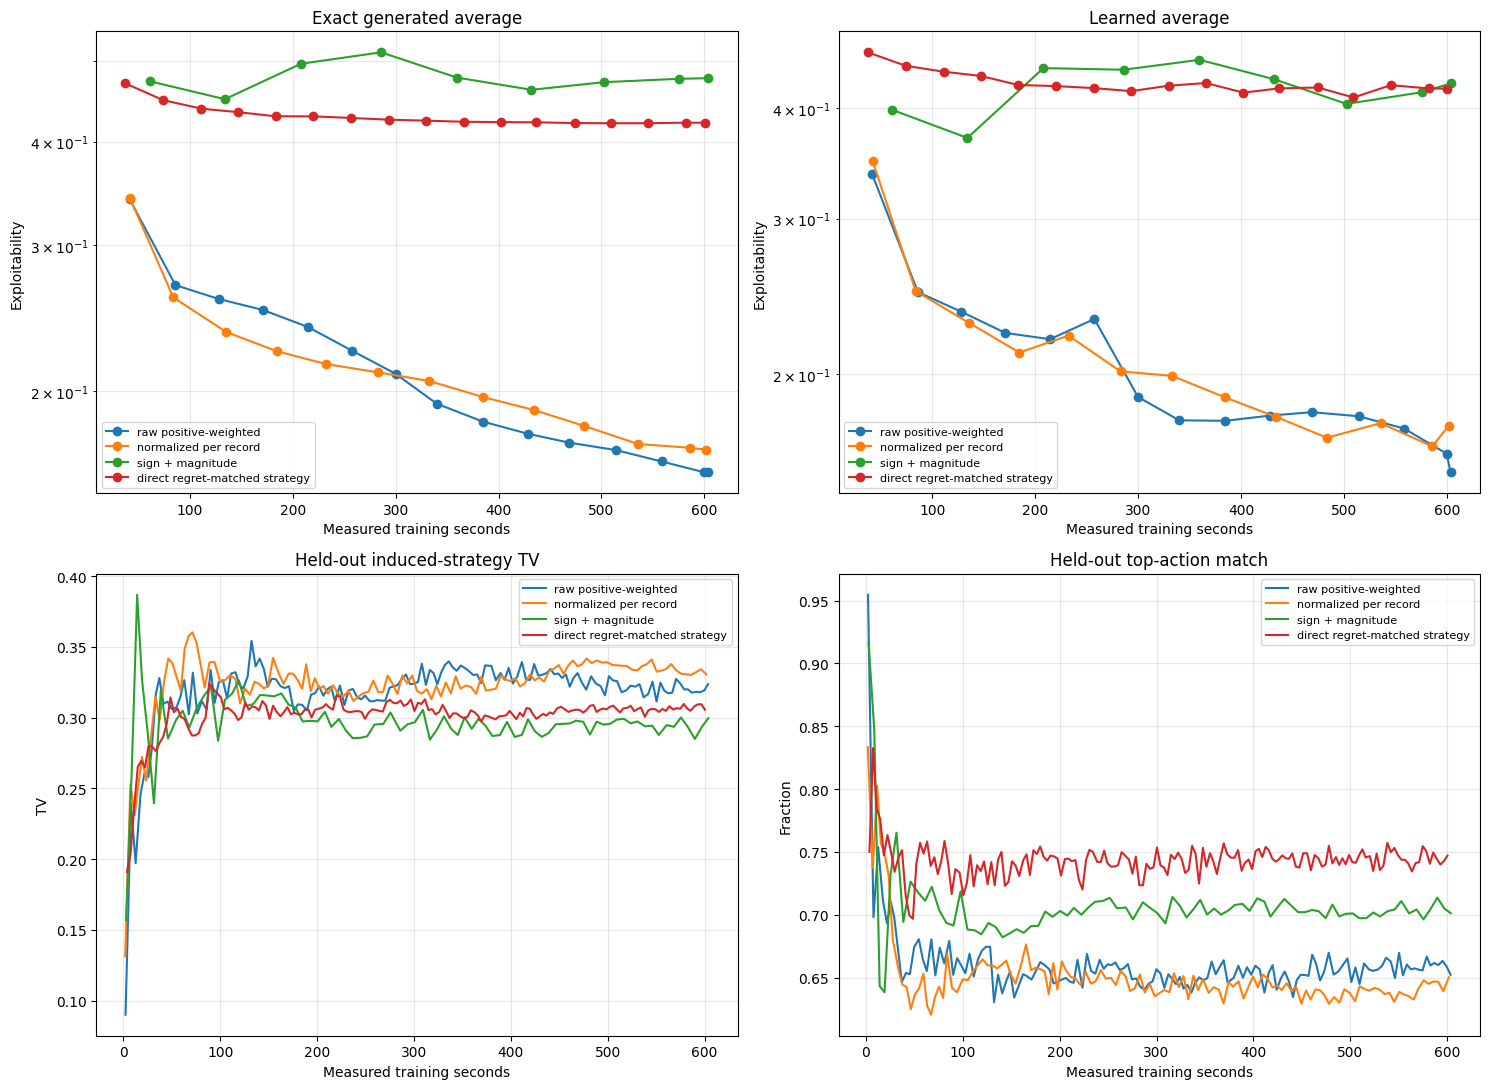

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for run in runs:
    seconds = evaluation_seconds(run)
    axes[0, 0].plot(seconds, exploitability_values(run, 'exact_average_predicted_avg'), marker='o', label=run['label'])
    axes[0, 1].plot(seconds, exploitability_values(run, 'predicted_avg'), marker='o', label=run['label'])
    validation_x, strategy_tv = validation_series(run, 'advantage', 'strategy_tv')
    _, top_match = validation_series(run, 'advantage', 'top_action_match')
    axes[1, 0].plot(validation_x, strategy_tv, label=run['label'])
    axes[1, 1].plot(validation_x, top_match, label=run['label'])

for ax, title, ylabel, log_y in zip(
    axes.flat,
    ('Exact generated average', 'Learned average', 'Held-out induced-strategy TV', 'Held-out top-action match'),
    ('Exploitability', 'Exploitability', 'TV', 'Fraction'),
    (True, True, False, False),
):
    ax.set(title=title, xlabel='Measured training seconds', ylabel=ylabel)
    if log_y:
        ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout();


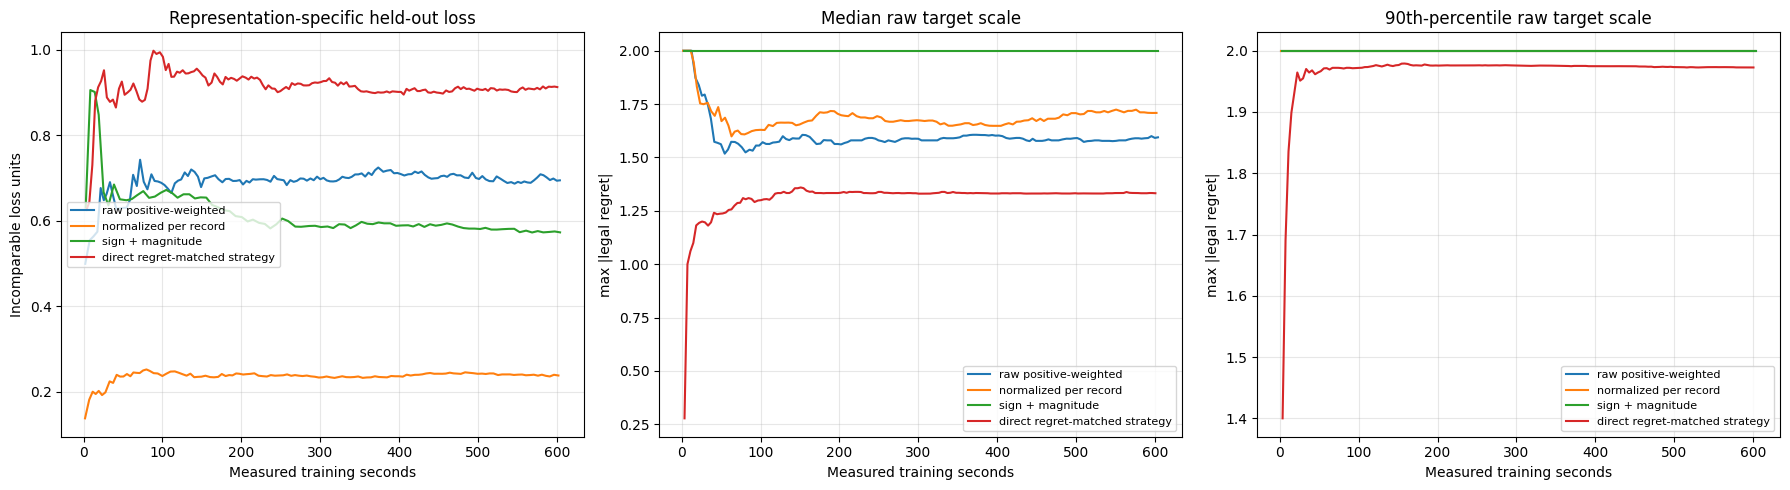

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for run in runs:
    validation_x, representation_loss = validation_series(run, 'advantage', 'representation_loss')
    _, target_scale_median = validation_series(run, 'advantage', 'target_scale_median')
    _, target_scale_p90 = validation_series(run, 'advantage', 'target_scale_p90')
    axes[0].plot(validation_x, representation_loss, label=run['label'])
    axes[1].plot(validation_x, target_scale_median, label=run['label'])
    axes[2].plot(validation_x, target_scale_p90, label=run['label'])

for ax, title, ylabel in zip(
    axes,
    ('Representation-specific held-out loss', 'Median raw target scale', '90th-percentile raw target scale'),
    ('Incomparable loss units', 'max |legal regret|', 'max |legal regret|'),
):
    ax.set(title=title, xlabel='Measured training seconds', ylabel=ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout();


In [9]:
summary_rows = []
for run in runs:
    exact = exploitability_values(run, 'exact_average_predicted_avg')
    learned = exploitability_values(run, 'predicted_avg')
    current = exploitability_values(run, 'current_predicted_avg')
    seconds = evaluation_seconds(run)
    _, representation_loss = validation_series(run, 'advantage', 'representation_loss')
    _, strategy_tv = validation_series(run, 'advantage', 'strategy_tv')
    _, top_match = validation_series(run, 'advantage', 'top_action_match')
    _, target_scale_median = validation_series(run, 'advantage', 'target_scale_median')
    training = run['logs']['training_series']
    summary_rows.append({
        'variant': run['label'],
        'parameters per advantage network': run['parameters_per_advantage_network'],
        'iterations completed': run['iterations'],
        'final exact-average exploitability': exact[-1],
        'best exact-average exploitability': exact.min(),
        'exact-average normalized AUC': normalized_auc(exact, seconds),
        'final learned-average exploitability': learned[-1],
        'final learned-minus-exact gap': learned[-1] - exact[-1],
        'final current exploitability': current[-1],
        'final representation-specific loss': representation_loss[-1],
        'final held-out induced-strategy TV': strategy_tv[-1],
        'final top-action match': top_match[-1],
        'final median raw target scale': target_scale_median[-1],
        'mean traversal s': np.mean([record['timing']['traversal_s'] for record in training]),
        'mean advantage fit s': np.mean([record['timing']['advantage_training_s'] for record in training]),
        'mean strategy fit s': np.mean([record['timing']['strategy_training_s'] for record in training]),
    })

summary_df = pd.DataFrame(summary_rows).set_index('variant')
summary_df.style.format(precision=6).background_gradient(
    subset=['final exact-average exploitability', 'best exact-average exploitability', 'exact-average normalized AUC'],
    cmap='RdYlGn_r',
)


,parameters per advantage network,iterations completed,final exact-average exploitability,best exact-average exploitability,exact-average normalized AUC,final learned-average exploitability,final learned-minus-exact gap,final current exploitability,final representation-specific loss,final held-out induced-strategy TV,final top-action match,final median raw target scale,mean traversal s,mean advantage fit s,mean strategy fit s
variant,,,,,,,,,,,,,,,
raw positive-weighted,73485,141,0.159626,0.159531,0.212241,0.154736,-0.004891,0.316735,0.694372,0.323714,0.652282,1.594275,2.996765,0.858113,0.425944
normalized per record,73485,123,0.169860,0.169860,0.210744,0.174728,0.004868,0.287503,0.237503,0.330638,0.650260,1.708616,3.394049,1.010912,0.487394
sign + magnitude,76826,84,0.477190,0.450133,0.478307,0.426959,-0.050232,0.673781,0.572587,0.299624,0.701172,2.000000,5.462814,1.223627,0.502469
direct regret-matched strategy,73485,165,0.421546,0.421012,0.428686,0.421203,-0.000343,0.416731,0.912651,0.305535,0.747020,1.332331,2.098386,1.057382,0.482712


## Interpretation priorities

1. Select primarily using exact generated-average normalized AUC and endpoint.
2. Check whether the learned average still tracks the exact generated average; a large gap would indicate the average network became a bottleneck.
3. Use induced-strategy TV and top-action match as common approximation diagnostics across all variants.
4. Do not compare representation-specific loss values directly: MSE, sign-plus-magnitude loss, and strategy cross-entropy have different units.
5. Per-record normalization is intentionally scientifically impure: it tests whether changing the expected target is nevertheless beneficial in practice.

If a variant clearly wins, the next step is a paired-seed confirmation against the raw positive-weighted baseline before changing production code.